# 8.2 OpenOneRec：受约束列表生成实战

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

如何把推荐列表变成 token 序列，同时保证解码结果属于真实目录、没有重复并可接受奖励对齐？

## Setup

本 Notebook 的默认真实数据是 **KuaiRand Semantic-ID（smoke 教学适配器）；full 档读取授权的 RecIF-Bench 本地副本**。`smoke` 档读取仓库内可审计的确定性切片，`full` 档扩大到官方完整文件；两档都不制造交互、曝光、标签或行为序列。切片规则、源地址、哈希与许可记录在 `data/README.md` 及对应数据目录。 **生成式章节默认要求 CUDA；无 CUDA 时只允许自动化测试执行 CPU basic smoke，不进行完整精度验证。**

**主要资料：** [Kuaishou OpenOneRec](https://github.com/Kuaishou-OneRec/OpenOneRec)

In [1]:
from pathlib import Path
import os, sys, json
import torch
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ARTIFACT_ROOT = Path(os.environ.get("RECSYS_ARTIFACT_ROOT", PROJECT_ROOT)).expanduser().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.environ.setdefault("RECSYS_PROFILE", "full")
PROFILE = os.environ["RECSYS_PROFILE"]
CUDA_AVAILABLE = torch.cuda.is_available()
DATASET_KEY = "openonerec-recif"
# Setup 只声明执行边界。完整数据由章节 runner 在 Train & Inference 单元按需读取，
# 避免仅打开 Notebook 就解析数千万行文件。
REAL_DATASET = {
    "dataset": DATASET_KEY,
    "profile": PROFILE,
    "loading": "lazy: chapter runner owns loading and returns executed provenance",
    "randomly_fabricated_rows": 0,
}
print({"profile": PROFILE, "project_root": str(PROJECT_ROOT), "artifact_root": str(ARTIFACT_ROOT), "dataset_boundary": REAL_DATASET,
       "cuda_available": CUDA_AVAILABLE,
       "cuda_device": torch.cuda.get_device_name(0) if CUDA_AVAILABLE else None})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

{'profile': 'smoke', 'project_root': '<ARTIFACT_ROOT>', 'artifact_root': '<ARTIFACT_ROOT>', 'dataset_boundary': {'dataset': 'openonerec-recif', 'profile': 'smoke', 'loading': 'lazy: chapter runner owns loading and returns executed provenance', 'randomly_fabricated_rows': 0}, 'cuda_available': False, 'cuda_device': None}


## 学习地图

1. 从原始论文理解系统约束；
2. 用可手算数字读懂公式和形状；
3. 检查数据、切分与标签；
4. 使用工业框架模型类训练；
5. 分开验证训练、推理和测试；
6. 用实际输出讨论失败边界。

**本节问题：** 如何把推荐列表变成 token 序列，同时保证解码结果属于真实目录、没有重复并可接受奖励对齐？

**阅读约定：** 通用数学通过 3.0 基础课程链接回看；本页只详细推导论文引入或改造的数学。第一次阅读先追踪输入、输出和形状，再看梯度。

## Paper & Context

OneRec（快手，2025）把召回、粗排、精排的级联流水线替换成单一 encoder-decoder 生成模型：内容 embedding 经均衡 K-Means 残差量化成 Semantic ID，decoder 自回归生成整屏 session，再用 IPA（自采样 + reward 模型 + 迭代 DPO）对齐偏好。OpenOneRec 展示这一流程的开放实现。smoke 档不冒充官方大模型训练，而是复现最关键的数据契约：item 到 Semantic ID、teacher forcing、trie 约束和合法性压力测试。

**来源：** [Kuaishou OpenOneRec](https://github.com/Kuaishou-OneRec/OpenOneRec)

### 原文实验设计与关键结论

原文 Table 1（离线，指标由 reward 模型估计而非真实行为）：OneRec-1B+IPA 的 swt mean/max 为 0.1025/0.1933，OneRec-1B 为 0.0991/0.1529，TIGER-1B 为 0.0873/0.1368，SASRec 仅 0.0375/0.0803；IPA 优于 DPO/IPO/cDPO/rDPO/CPO/simPO/S-DPO 全部对比变体。Table 2（快手主页面 1% 流量在线 A/B）：OneRec-1B+IPA 总观看时长 +1.68%、平均观看时长 +6.56%（摘要约写作 1.6%）。实现细节：Semantic ID 3 层、每层 8192 簇，历史 n=256、session m=5，MoE 24 专家每 token 激活 2 个，beam size 128，推理仅 13% 参数激活；0.05B→1B 规模消融持续提升。以上是快手业务口径，教程在 KuaiRand 上复现 Semantic ID、trie 约束与列表指标契约，数值不可相减。

请区分三层证据：论文中的离线实验、本 Notebook 验证的代码链路、生产系统尚需验证的在线收益。三者不能互相替代。

## Reproduction Contract

**正式数据：** OpenOneRec RecIF-Bench  
**资源 ID：** `openonerec-recif`  
**切分：** official release + benchmark_data task test sets  
**指标：** Recall@32, AUC, LLM Score  
**与论文比较边界：** gated 授权副本；对齐 OpenOneRec 官方 SID 目录与指令任务，只读本地副本不二次分发

`full` 只有在运行输出证明数据、切分、候选集、模型配置与指标均对齐时，才可能进入论文数值比较；它不是把教学适配器自动变成论文复现的开关。`smoke` 只做张量、损失和推理链路回归。

## Model Structure & Formula Walkthrough

![Figure 2 · OneRec overall framework](/static/paper-figures/onerec.webp)

> **论文原图节选** · Figure 2 · OneRec overall framework · PDF p.3。下图直接截取自原文，用于对照下方公式与代码。

### 关键模块

- **Encoder-Decoder 生成**：编码器读用户行为序列，解码器自回归生成高价值 session 中物品的 Semantic ID。
- **MoE + 双重注意力**：解码器中堆叠 Casual Self-Attention、Cross-Attention（读编码器 key/value）和 MoE 前馈层，增大容量。
- **IPA 偏好对齐**：每轮用 beam search 采样多个列表，按 reward 模型选 chosen / rejected，再用 DPO 更新，循环自我提升。

### 结构：把物品变成可以“写”出来的 Semantic ID

先定记号：物品 $i$ 的内容 embedding（标题、标签等文本经预训练编码器得到）记为 $x_i$；量化器把它映射为 $m$ 级 token 元组 $s(i)=(c_1,\ldots,c_m)$，每个 $c_j$ 是第 $j$ 层码本里的一个编号。

RQ-VAE 的“残差”就是上一层还没解释掉的部分。令编码器输出 $z_i=E(x_i)$、初始残差 $r_i^{(0)}=z_i$；第 $\ell$ 层从码本 $C_\ell$ 选最近码字，再把它扣掉：

$$c_\ell=\arg\min_c\|r_i^{(\ell-1)}-C_\ell[c]\|_2^2,\qquad r_i^{(\ell)}=r_i^{(\ell-1)}-C_\ell[c_\ell],$$
$$\hat z_i=\sum_{\ell=1}^{m}C_\ell[c_\ell],\qquad s(i)=(c_1,\ldots,c_m).$$

例如 $z=(0.9,0.7)$，第一层选 $(0.8,0.4)$ 后残差是 $(0.1,0.3)$；第二层再选 $(0.1,0.25)$，重建为 $(0.9,0.65)$，只剩 $(0,0.05)$ 未解释。RQ-VAE 用重建误差让 $\hat z$ 接近 $z$，并用 codebook/commitment 项让编码器输出和码字彼此靠近；这些损失训练的是“如何编码物品”，不是推荐点击损失。

OneRec 指出普通残差量化可能形成 hourglass：少数码点挤满物品，多数闲置，热门前缀导致 trie 分支失衡。它改用逐层均衡 K-Means，并约束每个簇的分配数近似 $|V|/K$（论文 Algorithm 1，每层 8192 簇、共 3 层）。两种方法的**接口相同**：都把物品交给生成器一个固定长度 token 元组；内部目标不同：RQ-VAE 优先重建，均衡量化还显式控制 token 使用率。于是不能把“使用 Semantic ID”自动写成“运行了 RQ-VAE”。

| 符号 | 含义 |
|---|---|
| $H^u$ | 用户 $u$ 的历史行为序列（OneRec 取 $n=256$ 条） |
| $S$ | 一个 session：一次请求返回的列表（训练取 $m=5$ 个物品） |
| $s_i^j$ | 第 $i$ 个物品第 $j$ 层 Semantic ID token |
| $y_t$ | 生成序列第 $t$ 步的 token |
| $x$ | 编码器对用户历史的表示（条件上下文） |

### 链式分解：一个列表的概率是一串条件概率的乘积

自回归生成把“生成整个 session”分解成一步步“接龙”：

$$P(y|x)=\prod_{t=1}^{T}P(y_t\mid y_{<t},x),\qquad L_{CE}=-\sum_t\log P(y_t^*|y_{<t}^*,x).$$

手算一步：词表只有 $\{a,b,c\}$，某步模型给出 $P(a|x)=0.5,\ P(b|x)=0.3,\ P(c|x)=0.2$。若正确 token 是 $a$，该步损失 $-\log 0.5\approx0.693$；若模型把概率押错，比如 $P(a|x)=0.1$，损失变成 $2.303$，约 3.3 倍。整个列表的损失是各步相加，所以模型必须步步都把概率质量放在真实 token 上。再算一条两步链：$P(y_1=a|x)=0.5$、$P(y_2=b|y_1=a,x)=0.4$，则 $P(a,b|x)=0.5\times0.4=0.2$，链越长概率越小，$-\log$ 把它们变成可相加的损失。

teacher forcing 是训练时的“提示许可”：第 $t$ 步的输入不是模型自己上一步的输出，而是真实前缀 $y_{<t}^*$。好处是误差不会逐步放大；代价是训练与推理不一致——推理时模型只能看到自己刚生成的（可能出错的）前缀。

### trie：把“不许编造物品”变成查树

自回归模型可能生成目录里不存在的 token 组合。trie（前缀树）把全部合法 Semantic ID 存成一棵树：从根到叶子的一条路径就是一个真实物品。解码第 $t$ 步时，已生成前缀 $y_{<t}$ 定位到树上某个节点，logits 里只保留该节点的子节点，其余置 $-\infty$ 再 softmax。

走一遍小例子：目录里有 4 个物品，Semantic ID 为 $(1,3)$、$(1,4)$、$(2,3)$、$(2,5)$。根节点的合法后继是 $\{1,2\}$；若第一步生成 $1$，第二步只允许 $\{3,4\}$——即使模型给 $5$ 打了 0.9 的概率也会被屏蔽。约束生成因此保证非法率为 0，但合法不等于相关：模型仍要把最高的合法概率给对物品。

### DPO：只拉开“好列表”和“差列表”的差距

偏好对齐阶段不教模型“什么是标准答案”，只教它“哪个列表更好”。记号：$y^+$ 是 chosen（reward 模型打分最高的采样列表），$y^-$ 是 rejected（打分最低），$\pi$ 是当前模型，$\pi_{ref}$ 是冻结的参考模型（防止跑偏），$\beta$ 控制偏离参考模型的惩罚强度：

$$L_{DPO}=-\log\sigma\{\beta[(\log\pi(y^+|x)-\log\pi_{ref}(y^+|x))-(\log\pi(y^-|x)-\log\pi_{ref}(y^-|x))]\}.$$

直觉来自大括号的符号：它是“chosen 相对参考模型的对数概率增量”减去“rejected 的”。若 chosen 被抬高 $+0.3$、rejected 变化 $-0.1$，差值为 $0.4$，$\sigma(0.4)\approx0.60$，损失 $-\log0.60\approx0.51$；若方向反了，差值 $-0.4$，损失 $-\log0.40\approx0.92$。梯度只做一件事——把 chosen 与 rejected 的差距拉大。OneRec 的 IPA 把差距来源换成“自己 beam search 采样 128 个列表、reward 模型打分、最好当 chosen 最差当 rejected”，每轮用新模型重新采样，且只用 1% 训练数据做对齐（论文 Figure 4 显示比例提到 5% 收益有限，GPU 成本却线性上升）。

### Reward 的证据边界

reward 模型 $R(x,y)$ 只是用历史反馈训练出的代理评分器，不是真实用户满意度，也不是线上因果收益。IPA 在模型自己采样的 128 个列表中按 $R$ 选 best/worst；DPO 随后只学习这对相对顺序，既不会直接优化真实观看时长，也无法修复 reward 模型没见过的偏差。trie 又只保证“目录合法”，不保证相关、多样或公平。因此三层验收必须分开：token 交叉熵检验模仿数据，reward/DPO 检验代理偏好，真正业务收益只能由同口径离线标签和线上 A/B 验证。smoke 实验只覆盖第一层与约束接口。

### 公式到代码

`run_openonerec` 展开教学 Semantic ID、teacher forcing 与 trie 解码；它没有训练官方 RQ-VAE/均衡量化器或 reward 模型。完整 OpenOneRec 配置留在官方框架，教程明确区分接口、代理 reward 和线上效果。

阅读源码时按“张量形状 → 前向计算 → score → loss → metric”五步追踪，不需要一次读完整个工程文件。

## Math by Hand

### 通用先修（先回看 3.0 基础课程）

- [序列、标签与反馈](/notebooks/3_2_data_ml_basics#observation-label)
- [embedding 与向量量化接口](/notebooks/3_3_linear_algebra#matmul-embedding)
- [条件概率链式法则](/notebooks/3_5_probability_statistics#conditional-chain)
- [序列 NLL 与 DPO](/notebooks/3_6_information_theory#sequence-nll-dpo)

### 本论文新增数学（本节详细推导）

残差量化到均衡 Semantic ID 的接口、trie 约束列表解码，以及 reward 模型边界内的迭代偏好对齐。

自回归分解 $P(y_1,\ldots,y_T|x)=\prod_tP(y_t|y_{<t},x)$，表示每一步根据上下文和已生成 token 预测下一 token。trie 像目录树：前缀 $(1,2)$ 下只允许真实后继 $\{3,4\}$。DPO 只需要 $\sigma$ 与 $\log$ 的直觉：$-\log\sigma(z)$ 在 $z$ 增大时减小，因此损失鼓励 chosen 列表相对参考模型的对数概率增量高于 rejected。

下面用 NumPy/Matplotlib 验证直觉。二维图只是教学投影，工业 embedding 虽有更多维，计算规则相同。

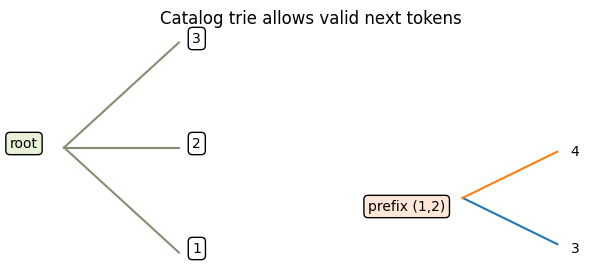

In [2]:
import matplotlib.pyplot as plt
fig,ax=plt.subplots(figsize=(7,3)); ax.axis('off'); ax.text(.05,.5,'root',bbox=dict(boxstyle='round',fc='#e8f2d6'))
for y,node in zip([.25,.5,.75],['1','2','3']):
    ax.text(.32,y,node,bbox=dict(boxstyle='round',fc='white')); ax.plot([.13,.30],[.5,y],color='#809070')
ax.text(.58,.35,'prefix (1,2)',bbox=dict(boxstyle='round',fc='#ffe8d7')); ax.text(.88,.25,'3'); ax.text(.88,.48,'4')
ax.plot([.72,.86],[.38,.27]); ax.plot([.72,.86],[.38,.49]); ax.set_title('Catalog trie allows valid next tokens'); plt.show()

## Data

### 权威 full 协议（效果验收目标）

**正式数据：** OpenOneRec RecIF-Bench  
**资源 ID：** `openonerec-recif`  
**切分：** official release + benchmark_data task test sets  
**指标：** Recall@32, AUC, LLM Score  
**与论文比较边界：** gated 授权副本；对齐 OpenOneRec 官方 SID 目录与指令任务，只读本地副本不二次分发

### smoke 教学适配器（默认 runner 实际读取）

KuaiRand-Pure 的真实视频 tag、music type 与 item 分区形成教学 Semantic ID；真实反馈只用于小型 token/约束链路。full 档读取已授权的 RecIF-Bench 本地副本（官方 pid→Semantic ID 目录与 release 交互），smoke 不把本地 chosen/rejected 当成官方 reward 数据。

下方运行结果打印的 provenance 才是本次执行事实；若资源、统计或切分与 full 协议不一致，就必须标记为不可比较。

**防泄漏清单：**按时间切分；item 映射只表达已知目录，不读取测试标签；低评分或未点击负反馈均来自数据中的已观察行；序列只看预测时刻以前；测试集只在最后评价。无 CUDA 时的 CPU basic smoke 只验证基本功能，不产出精度结论。

## Model & Framework

OpenOneRec 官方训练配置负责 full profile；本 Notebook 的 PyTorch 小生成器验证相同 token/trie 契约、训练损失和合法性。

smoke 档强调模型类、张量契约和指标链路真实可运行；full 档应替换原始数据、分布式配置、索引/服务和资源预算，而不是只增加 epoch。 本节默认使用 CUDA、混合精度与 TF32；没有 CUDA 时只运行缩小后的 CPU basic smoke，结果不进入完整精度结论。

In [3]:
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from importlib import import_module
from recsys_lab.runtime import print_progress, save_records

# 算法实现就在当前章节目录，不再通过公共模块隐藏。
chapter_train = import_module("chapter_code.8_2_openonerec_practice.train")
run_openonerec = chapter_train.run_openonerec

print("实际执行函数源码（包含数据、训练、推理和测试）：")
print(inspect.getsource(run_openonerec))

实际执行函数源码（包含数据、训练、推理和测试）：
def run_openonerec(
    epochs: int = 32,
    cpu_smoke: bool = False,
    *,
    progress: ProgressCallback | None = None,
) -> dict:
    # 1) 固定参数初始化，并读取本章指定的真实数据切片。
    emit_progress(progress, stage="data_prepare", current=0, total=1, message="加载数据并构造 Semantic ID 训练序列")
    seed_everything(); device = _training_device(cpu_smoke)
    sample_rows = 256 if device.type == "cpu" else 2000
    if full_profile():
        users, catalog_frame, provenance = _real_openonerec_dataset()
        # 官方 Semantic ID：pid → 三层整数编码，+1 偏移把 0 留给起始符。
        item_to_code = {int(row.pid): tuple(int(value) + 1 for value in row.sid) for row in catalog_frame.itertuples()}
        catalog = set(item_to_code.values())
        # 训练序列来自 release 中真实 hist_video_pid（只保留有官方 SID 映射的物品）。
        sequences = []
        for row in users.itertuples():
            for pid in list(row.hist_video_pid)[-9:]:
                code = item_to_code.get(int(pid))
                if code is not None:
       

## Train & Inference

下一格固定 seed、构造数据、实例化模型、训练并进入推理路径。生成式章节在 CUDA 上执行完整评测；CPU 环境只验证缩小后的基本张量与约束链路。

In [4]:
result = run_openonerec(cpu_smoke=not torch.cuda.is_available(), progress=print_progress)
REAL_DATASET = result['dataset']
assert REAL_DATASET['randomly_fabricated_rows'] == 0
print({'framework': result['framework'], 'dataset': result.get('dataset', {}),
       'device': result.get('device'), 'validation_mode': result.get('validation_mode')})
print('inference contract:', '自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。')
assert np.isfinite(result['loss_curve']).all()
print('loss:', round(result['loss_curve'][0],4), '→', round(result['loss_curve'][-1],4))

[data_prepare] 0/1 加载数据并构造 Semantic ID 训练序列


[data_prepare] 1/1 training_codes=256


[train] 0/2 训练生成式列表代理模型


[train] 1/2 loss=4.27758


[train] 2/2 loss=3.94765


...

[baseline] 0/1 构造无约束 argmax 对照


[baseline] 1/1


[evaluate] 0/1 校验目录约束


[evaluate] 1/1 invalid_constrained=0


{'framework': 'OpenOneRec contract + PyTorch executable proxy', 'dataset': {'dataset': 'KuaiRand-Pure (Kuaishou, CIKM 2022)', 'source': 'https://zenodo.org/records/10439422/files/KuaiRand-Pure.tar.gz', 'source_sha256': 'c814bf6f3624c0cfae83c57de3df26b2ed206e5c57bab4c4dcbfabbabe20cbf0', 'license_file': '<ARTIFACT_ROOT>/data/kuairand-pure/LICENSE', 'slice_rule': 'top 256 users by standard-feed interaction count; ties by user_id; all standard and random-policy rows for those users retained', 'profile': 'smoke', 'local_resource': '<ARTIFACT_ROOT>/data/kuairand-pure/standard_interactions.csv', 'rows_used': 29602, 'users_used': 96, 'items_used': 2200, 'time_min_utc': '2022-04-09T04:29:16+00:00', 'time_max_utc': '2022-05-08T15:50:58+00:00', 'targets': 'observed is_click, long_view, is_like and other feed feedback', 'randomly_fabricated_rows': 0, 'semantic_catalog_size': 1176, 'training_codes': 256, 'code_source': 'observed KuaiRand video tag + music type + item id partition'}, 'device': 'cpu'

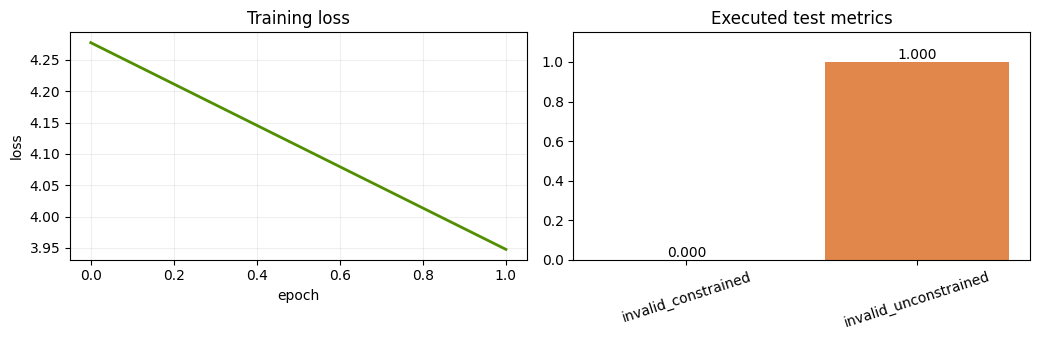

,value
invalid_constrained,0.0
invalid_unconstrained,1.0


In [5]:
fig,axes=plt.subplots(1,2,figsize=(10.5,3.5))
axes[0].plot(result['loss_curve'],color='#4f8f00',lw=2); axes[0].set(title='Training loss',xlabel='epoch',ylabel='loss'); axes[0].grid(alpha=.2)
metrics={'invalid_constrained': result['invalid_constrained'], 'invalid_unconstrained': result['invalid_unconstrained']}
axes[1].bar(range(len(metrics)),list(metrics.values()),color=['#7ca832','#e1874b','#6d88a4'][:len(metrics)])
axes[1].set_xticks(range(len(metrics)),list(metrics),rotation=18); axes[1].set(title='Executed test metrics',ylim=(0,max(1.0,max(metrics.values())*1.15)))
for index,value in enumerate(metrics.values()): axes[1].text(index,value,f'{value:.3f}',ha='center',va='bottom')
plt.tight_layout(); plt.show(); display(pd.Series(metrics,name='value').to_frame())

In [6]:
# 论文数字只能在数据、切分、候选和指标全部同口径时相减。
paper_protocol = json.loads('{"dataset": "OpenOneRec RecIF-Bench", "resource": "openonerec-recif", "split": "official release + benchmark_data task test sets", "metrics": ["Recall@32", "AUC", "LLM Score"], "paper_comparison": "gated 授权副本；对齐 OpenOneRec 官方 SID 目录与指令任务，只读本地副本不二次分发"}')
paper_targets = paper_protocol.get('paper_targets', {})
metric_key = {'HitRate@10':'paper_protocol_hr@10', 'NDCG@10':'paper_protocol_ndcg@10',
              'AUC':'auc', 'LogLoss':'logloss'}
dataset_name = result.get('dataset', {}).get('dataset', '')
dataset_aligned = paper_protocol.get('dataset', '').split(',')[0].casefold() in dataset_name.casefold()
comparison_eligible = PROFILE == 'full' and dataset_aligned
rows=[]
for paper_metric,target in paper_targets.items():
    result_key=metric_key.get(paper_metric)
    value=result.get(result_key) if result_key else None
    rows.append({'metric':paper_metric,'tutorial':value,'paper':target,
                 'absolute_gap':None if value is None or not comparison_eligible else float(value)-float(target),
                 'comparable':comparison_eligible and value is not None})
if rows:
    display(pd.DataFrame(rows))
    if not comparison_eligible:
        print('NOT COMPARABLE：当前运行的数据/协议与论文不完全一致，不计算复现差值。')
else:
    print('论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。')

论文没有可公开、可同口径复现的绝对目标；本节只报告结构与公开协议验证。


## Test & Results Discussion

In [7]:
display(Markdown(f'''### 本次已执行结果

- 主指标 invalid_constrained = **{result['invalid_constrained']:.4f}**。
- 辅助指标 invalid_unconstrained = **{result['invalid_unconstrained']:.4f}**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **{result['loss_curve'][0]:.4f}** 降到 **{result['loss_curve'][-1]:.4f}**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 合法率只是底线，不等于相关性；还需看 Recall/NDCG、重复率、多样性、P99、目录更新和奖励偏差。

### 工业边界

自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。
'''))

### 本次已执行结果

- 主指标 invalid_constrained = **0.0000**。
- 辅助指标 invalid_unconstrained = **1.0000**。
- 本节没有把不同任务的数值伪装成 baseline；章节总结只做同口径比较。
- 训练损失从 **4.2776** 降到 **3.9477**。损失下降只说明优化工作，不等于泛化或业务收益。
- **结果解释：** 合法率只是底线，不等于相关性；还需看 Recall/NDCG、重复率、多样性、P99、目录更新和奖励偏差。

### 工业边界

自回归每一步应用目录 trie、去重和长度约束；随后可用奖励模型或 DPO 调整整列价值。

上线前还需验证延迟、吞吐、内存/显存、数据新鲜度、校准、回滚和线上 A/B。


In [8]:
record={
    'algorithm': 'OpenOneRec：受约束列表生成实战',
    'primary_metric': 'invalid_constrained', 'primary_value': float(result['invalid_constrained']),
    'secondary_metric': 'invalid_unconstrained', 'secondary_value': float(result['invalid_unconstrained']),
    'baseline_metric': None,
    'baseline_value': float(result[None]) if False else None,
    'framework': result['framework'], 'source_notebook': '8_2_openonerec_practice',
    'validation_mode': result.get('validation_mode', 'standard'),
    'dataset': result['dataset']['dataset'],
    'randomly_fabricated_rows': int(result['dataset']['randomly_fabricated_rows'])
}
path=save_records('chapter_8','8_2_openonerec_practice',[record]); print('saved:',path.relative_to(ARTIFACT_ROOT))

saved: results/chapter_8/8_2_openonerec_practice.json


## Checks

自动断言用于防止数据、训练和指标链路静默失效，不是效果证明。

In [9]:
assert result['loss_curve'][-1] < result['loss_curve'][0]
assert 0 <= float(result['invalid_constrained']) <= 1
assert np.isfinite(float(result['invalid_unconstrained']))
print('PASS：数据、训练、推理、测试和结果产物均已验证。')

PASS：数据、训练、推理、测试和结果产物均已验证。


## Next Steps

1. 换成对应公开数据的完整时间切分；2. 增加强 baseline 与消融；3. 记录效果、延迟和成本；4. 映射到 TorchEasyRec/官方 full profile；5. 只在相同候选与数据口径下比较。